In [8]:
import json

def process_pitch_data(input_file, output_file):
    # Load the JSON file
    with open(input_file, "r") as file:
        data = json.load(file)

    print(f"Total sequences: {len(data)}")
    processed_data = []

    for song_name, sequences in data.items():  # Iterate over song names and sequences
        for sequence in sequences:
            # Extract pitch values and remove zero-pitch values
            filtered_sequence = [entry["pitch"] for entry in sequence if entry["pitch"] != 0]

            if not filtered_sequence:
                print("Filtered sequence is empty!")

            # Generate input-output pairs
            for i in range(len(filtered_sequence) - 10):
                input_seq = filtered_sequence[i:i + 10]  # Keep as numerical values
                output_pitch = filtered_sequence[i + 10]  # Keep as numerical value
                processed_data.append({"input": input_seq, "output": output_pitch})

    if len(processed_data) == 0:
        print("No input-output pairs were generated!")

    # Save the processed dataset
    with open(output_file, "w") as outfile:
        json.dump(processed_data, outfile, indent=4)

    print(f"Processed data saved to {output_file}")


# Example usage
input_file = "/content/extracted_pitch_sequences.json"  # Replace with your actual input file path
output_file = "/content/processed_pitch_dataset.json"  # Replace with your desired output file path
process_pitch_data(input_file, output_file)


Total sequences: 1
Processed data saved to /content/processed_pitch_dataset.json


In [21]:
import json

def process_pitch_data(input_file, output_file):
    # Load the JSON file
    with open(input_file, "r") as file:
        data = json.load(file)

    print(f"Total sequences: {len(data)}")
    processed_data = []

    for song_name, sequences in data.items():  # Iterate over song names and sequences
        for sequence in sequences:
            # Extract pitch values and remove zero-pitch values
            filtered_sequence = [entry["pitch"] for entry in sequence if entry["pitch"] != 0]

            if not filtered_sequence:
                print("Filtered sequence is empty!")

            # Generate input-output pairs
            for i in range(len(filtered_sequence) - 10):
                pitch=filtered_sequence[i]
                processed_data.append(pitch)

    if len(processed_data) == 0:
        print("No input-output pairs were generated!")

    # Save the processed dataset
    with open(output_file, "w") as outfile:
        json.dump(processed_data, outfile, indent=4)

    print(f"Processed data saved to {output_file}")


# Example usage
input_file = "/content/extracted_pitch_sequences.json"  # Replace with your actual input file path
output_file = "/content/processed_pitch_pairs.json"  # Replace with your desired output file path
process_pitch_data(input_file, output_file)


Total sequences: 1
Processed data saved to /content/processed_pitch_pairs.json


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import json
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# ==== 🔹 Step 1: Load JSON Data ====
with open("/content/processed_pitch_dataset.json", "r") as f:
    data = json.load(f)

# Extract input-output sequences
X = np.array([seq["input"] for seq in data], dtype=np.float32)  # Shape: (num_samples, 10)
Y = np.array([seq["output"] for seq in data], dtype=np.float32).reshape(-1, 1)  # Shape: (num_samples, 1)

# ==== 🔹 Step 2: Normalize Data ====
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
Y_tensor = torch.tensor(Y_scaled, dtype=torch.float32)

# ==== 🔹 Step 3: Dataset & DataLoader ====
class PitchDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

dataset = PitchDataset(X_tensor, Y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# ==== 🔹 Step 4: Transformer Model ====
class PitchTransformer(nn.Module):
    def __init__(self, input_dim, embed_dim, num_heads, ff_dim, num_layers):
        super(PitchTransformer, self).__init__()
        self.embedding = nn.Linear(input_dim, embed_dim)

        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)

        self.decoder = nn.Linear(embed_dim, 1)

    def forward(self, x):
        x = self.embedding(x)  # Shape: (batch_size, seq_len) → (batch_size, seq_len, embed_dim)

        if x.dim() == 2:
            x = x.unsqueeze(1)  # Add sequence dimension: (batch_size, 1, embed_dim)

        x = self.transformer_encoder(x)  # Shape: (batch_size, seq_len, embed_dim)
        x = x[:, -1, :]  # Take last time step's output
        return self.decoder(x)

# Model parameters
seq_len = 10
embed_dim = 64
num_heads = 4
ff_dim = 128
num_layers = 3

model = PitchTransformer(seq_len, embed_dim, num_heads, ff_dim, num_layers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==== 🔹 Step 5: Training Loop ====
num_epochs = 5
for epoch in range(num_epochs):
    total_loss = 0
    for X_batch, Y_batch in dataloader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs.squeeze(), Y_batch.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(dataloader)}")

# Save trained model
torch.save(model.state_dict(), "pitch_transformer.pth")


Epoch 1, Loss: 0.018797106164011864
Epoch 2, Loss: 0.003652773474866364
Epoch 3, Loss: 0.0026101227647872764
Epoch 4, Loss: 0.002163757920585653
Epoch 5, Loss: 0.0020763619073105835


In [11]:
import numpy as np
import torch

def generate_sancaras(model, input_seq, num_sancaras=4, length=1000, temperature=1.5):
    model.eval()
    sancaras = []  # Store generated sequences

    for _ in range(num_sancaras):
        generated_seq = list(input_seq)  # Start with the given input

        for _ in range(length):
            with torch.no_grad():
                input_tensor = torch.tensor(
                    scaler_X.transform(np.array([generated_seq[-10:]])), dtype=torch.float32
                ).unsqueeze(1)  # Shape: (1, seq_len, embed_dim)

                output = model(input_tensor).item()

                # 🔥 Apply Temperature Scaling
                scaled_output = output / temperature

                # Convert back to pitch scale
                denormalized_output = scaler_Y.inverse_transform([[scaled_output]])[0][0]

                # 🔄 Reduce excessive smoothing for variation
                denormalized_output = np.clip(denormalized_output, 480, 560)
                if len(generated_seq) > 1:
                    denormalized_output = (
                        0.7 * generated_seq[-1] + 0.3 * denormalized_output
                    )

                # 🎲 Add slight randomness to avoid getting stuck
                denormalized_output += np.random.uniform(-2, 2)

                generated_seq.append(denormalized_output)

        sancaras.append(np.array(generated_seq))  # Store the generated sequence

    return sancaras  # Return all generated sequences

# Example: Generate 4 new sancaras of length 100
generated_sancaras = generate_sancaras(model, X[0][:10], num_sancaras=4, length=100, temperature=1.5)

# Print one example sancara
print("Generated Sancara 1:", generated_sancaras[0])


Generated Sancara 1: [548.00518799 548.00518799 548.00518799 548.00518799 551.17974854
 551.17974854 551.17974854 551.17974854 551.17974854 551.17974854
 531.25860894 515.90532082 503.65591703 497.16167934 492.83681277
 489.50521614 488.07563558 485.496888   482.21026703 481.02519581
 481.68134918 481.47381073 481.86354371 480.51358875 481.90704242
 482.31818344 482.42609341 481.44437054 482.64955936 482.40812124
 482.90352903 480.37109761 479.10662085 479.48975314 479.5577
 479.29232646 480.60130069 479.95613013 481.73091428 481.96238996
 482.23160417 482.53406194 482.18043273 480.48324203 480.83124655
 482.12144287 480.87522346 481.18162993 479.78918092 481.66066511
 481.40223183 479.35626914 478.21408495 478.36852495 478.95885822
 481.1414436  482.39501365 481.66927803 481.20539977 480.31088071
 481.4682429  479.4660149  481.1158785  479.97309964 478.73748896
 479.26501254 479.67164171 479.29397716 479.8231279  481.41538496
 480.34993658 481.2691316  481.76433465 483.15220828 481.12

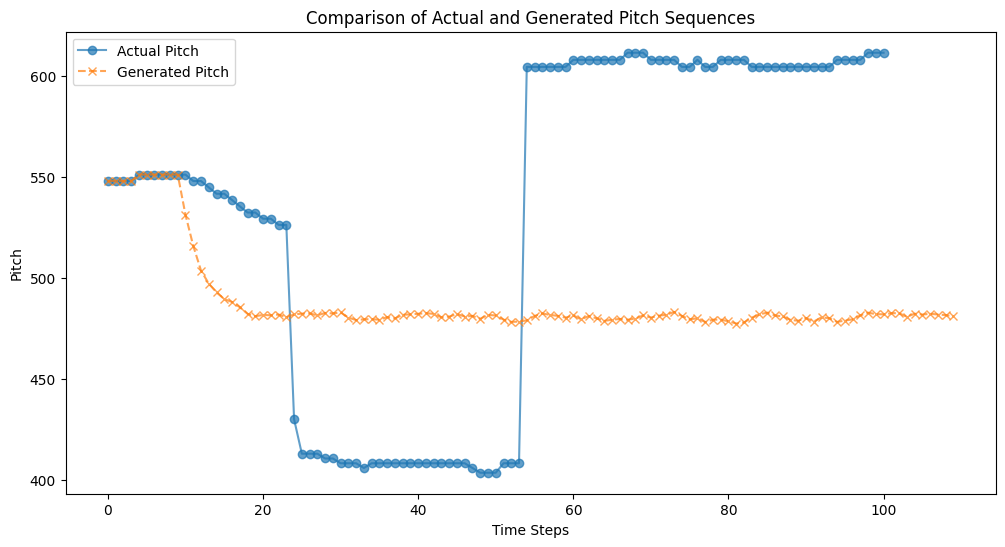

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Define actual and generated pitch sequences
act_pitch = [
    548.005188, 548.005188, 548.005188, 548.005188, 551.1797485, 551.1797485, 551.1797485, 551.1797485,
    551.1797485, 551.1797485, 551.1797485, 548.005188, 548.005188, 544.848877, 541.7108154, 541.7108154,
    538.5906982, 535.4886475, 532.40448, 532.40448, 529.3380127, 529.3380127, 526.2892456, 526.2892456,
    429.9555664, 412.917572, 412.917572, 412.917572, 410.5393372, 410.5393372, 408.1747742, 408.1747742,
    408.1747742, 405.8238525, 408.1747742, 408.1747742, 408.1747742, 408.1747742, 408.1747742, 408.1747742,
    408.1747742, 408.1747742, 408.1747742, 408.1747742, 408.1747742, 408.1747742, 408.1747742, 405.8238525,
    403.4864807, 403.4864807, 403.4864807, 408.1747742, 408.1747742, 408.1747742, 604.5480957, 604.5480957,
    604.5480957, 604.5480957, 604.5480957, 604.5480957, 608.0501709, 608.0501709, 608.0501709, 608.0501709,
    608.0501709, 608.0501709, 608.0501709, 611.5726318, 611.5726318, 611.5726318, 608.0501709, 608.0501709,
    608.0501709, 608.0501709, 604.5480957, 604.5480957, 608.0501709, 604.5480957, 604.5480957, 608.0501709,
    608.0501709, 608.0501709, 608.0501709, 604.5480957, 604.5480957, 604.5480957, 604.5480957, 604.5480957,
    604.5480957, 604.5480957, 604.5480957, 604.5480957, 604.5480957, 604.5480957, 608.0501709, 608.0501709,
    608.0501709, 608.0501709, 611.5726318, 611.5726318, 611.5726318
]

generated_pitch = np.array([
    548.00518799, 548.00518799, 548.00518799, 548.00518799, 551.17974854,
    551.17974854, 551.17974854, 551.17974854, 551.17974854, 551.17974854,
    531.25860894, 515.90532082, 503.65591703, 497.16167934, 492.83681277,
    489.50521614, 488.07563558, 485.496888, 482.21026703, 481.02519581,
    481.68134918, 481.47381073, 481.86354371, 480.51358875, 481.90704242,
    482.31818344, 482.42609341, 481.44437054, 482.64955936, 482.40812124,
    482.90352903, 480.37109761, 479.10662085, 479.48975314, 479.5577,
    479.29232646, 480.60130069, 479.95613013, 481.73091428, 481.96238996,
    482.23160417, 482.53406194, 482.18043273, 480.48324203, 480.83124655,
    482.12144287, 480.87522346, 481.18162993, 479.78918092, 481.66066511,
    481.40223183, 479.35626914, 478.21408495, 478.36852495, 478.95885822,
    481.1414436, 482.39501365, 481.66927803, 481.20539977, 480.31088071,
    481.4682429, 479.4660149, 481.1158785, 479.97309964, 478.73748896,
    479.26501254, 479.67164171, 479.29397716, 479.8231279, 481.41538496,
    480.34993658, 481.2691316, 481.76433465, 483.15220828, 481.12184162,
    479.48487306, 480.01814769, 478.14528108, 479.3208741, 479.34773476,
    478.520303, 477.39493734, 477.91402675, 480.30449988, 481.94359924,
    482.80609869, 481.3998306, 480.92552196, 479.20454932, 478.7777351,
    480.11798712, 478.38080845, 480.48810871, 480.04147871, 478.2142299,
    478.83193287, 479.48587771, 481.43941844, 482.77426849, 482.06004675,
    481.94489639, 482.52559353, 482.53578244, 480.70664999, 482.26665382,
    481.84462882, 482.25308399, 481.87478371, 481.59429128, 480.97822629
])

plt.figure(figsize=(12, 6))
plt.plot(act_pitch, label='Actual Pitch', marker='o', linestyle='-', alpha=0.7)
plt.plot(generated_pitch, label='Generated Pitch', marker='x', linestyle='--', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Pitch')
plt.title('Comparison of Actual and Generated Pitch Sequences')
plt.legend()
plt.show()